# 04 — Modelling & evaluation (Deliverable D: D1–D9; figures fig10–fig12)

Input: `data/processed/master_train.csv` and `master_test.csv` (cleaned + joined + engineered in `01_cleaning_and_integration.ipynb`); zone types from `02_analysis_report.ipynb`.
All scores are on **held-out later weeks of the train file**; the test file is never used.

**Split dates** (all times Addis local, EAT):
- Training data: 2025-01-01 00:00 up to each cut date.
- Main validation fortnight (D1, D2): **2025-10-18 00:00 – 2025-10-31 23:00**, trained on everything before 18 Oct.
- Rolling-origin folds (D3, D5, fig10): validation fortnights starting **6 Sep, 20 Sep, 4 Oct, 18 Oct**, each trained on everything before its start.
- Tuning split (D6): train before **23 Aug**, validate **23 Aug – 5 Sep**, so tuning never sees the evaluation fortnights.

Forecast horizon assumed: 14 days. Lags are at least 14 days old; weather comes from the cleaned hourly file, standing in for a forecast.

### Setup

In [1]:
import os
import time
import warnings
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import lightgbm as lgb
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.width", 170)
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
PROC_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)
CUTOFFS = pd.to_datetime(["2025-09-06", "2025-09-20", "2025-10-04", "2025-10-18"])
TUNE_CUTOFF = pd.Timestamp("2025-08-23")
HORIZON = pd.Timedelta(days=14)
SEED = 42

BLUE, ORANGE = "#2a78d6", "#eb6834"
LIGHT_BLUE, NEUTRAL = "#9ec5f4", "#c3c2b7"
INK, INK_2, INK_3, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "lines.linewidth": 2, "savefig.dpi": 150, "savefig.bbox": "tight",
})


def save(fig, name):
    """Save a figure to figures/ and show it."""
    fig.savefig(FIG_DIR / name)
    plt.show()

### Load the feature table and define feature groups

In [2]:
data = pd.read_csv(PROC_DIR / "master_train.csv", parse_dates=["pickup_hour"])
zone_type = pd.read_csv(PROC_DIR / "zone_types.csv", index_col="zone")["zone_type"]
ZONES = sorted(data["zone"].unique())
data["zone_code"] = data["zone"].map({z: i for i, z in enumerate(ZONES)})
data["zone_type"] = data["zone"].map(zone_type)
data["zone_type_code"] = data["zone_type"].astype("category").cat.codes
data["day_type"] = np.select([data["is_holiday"] == 1, data["is_weekend"] == 1], ["holiday", "weekend"], "weekday")

CALENDAR = ["hour", "dow", "is_weekend", "month", "days_to_month_end", "is_holiday", "is_school_break"]
ZONE = ["zone_code", "zone_type_code"]
TREND = ["trend_days", "lag_14d", "lag_21d", "lag_28d", "lag_mean_14_28d"]
WEATHER = ["temp_c", "rain_mm", "rain_3h", "rain_class", "humidity_pct", "wind_kmh", "weather_imputed"]
EVENTS = ["ev_in_window", "ev_attendance", "hours_to_next_event", "hours_since_event_end"] + \
         sorted(c for c in data.columns if c.startswith("ev_") and c not in ("ev_in_window", "ev_attendance"))
LEAKY = ["active_drivers", "avg_wait_min", "avg_fare_birr"]
BASE = CALENDAR + ZONE + TREND
FEATURES = BASE + WEATHER + EVENTS
FEATURE_GROUP = {**{f: "Weather" for f in WEATHER}, **{f: "Event" for f in EVENTS}}
print(data.shape, "|", len(FEATURES), "features")

(82742, 44) | 31 features


### Models (shared by every section)

In [3]:
LGBM_DEFAULT = dict(objective="poisson", n_estimators=800, learning_rate=0.05, num_leaves=63, min_child_samples=30,
                    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=SEED, verbose=-1)


def rmse(y, p):
    """Root mean squared error."""
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))


def mae(y, p):
    """Mean absolute error."""
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(p))))


def split(cutoff):
    """Train on everything before the cut date, validate on the next 14 days."""
    train = data[data["pickup_hour"] < cutoff]
    val = data[(data["pickup_hour"] >= cutoff) & (data["pickup_hour"] < cutoff + HORIZON)]
    return train, val


def timed(fn):
    """Wrap a fit/predict function so it also returns training seconds."""
    def run(train, val):
        t0 = time.perf_counter()
        pred, model = fn(train, val)
        return np.asarray(pred, dtype=float), model, time.perf_counter() - t0
    return run


@timed
def mean_predictor(train, val):
    """Baseline: the overall training mean for every zone-hour."""
    return np.full(len(val), train["trips"].mean()), None


@timed
def seasonal_naive(train, val, weeks=8):
    """Baseline: mean of the last `weeks` weeks for the same zone, weekday and hour."""
    recent = train[train["pickup_hour"] >= train["pickup_hour"].max() - pd.Timedelta(weeks=weeks)]
    m = recent.groupby(["zone", "dow", "hour"])["trips"].mean().rename("p")
    p = val.join(m, on=["zone", "dow", "hour"])["p"]
    return p.fillna(train["trips"].mean()).values, None


@timed
def ridge(train, val):
    """Ridge regression: one-hot zone x hour and weekday, scaled numeric features."""
    def prep(d):
        return d.assign(zone_hour=d["zone"] + "_" + d["hour"].astype(str))
    cat = ["zone_hour", "dow", "zone"]
    num = [f for f in FEATURES if f not in ZONE + ["hour", "dow"]]
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                             ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num)])
    m = make_pipeline(pre, Ridge(alpha=1.0)).fit(prep(train)[cat + num], train["trips"])
    return np.clip(m.predict(prep(val)[cat + num]), 0, None), m


@timed
def random_forest(train, val):
    """Random forest on all features (missing lags filled with the median)."""
    m = make_pipeline(SimpleImputer(strategy="median"),
                      RandomForestRegressor(n_estimators=150, min_samples_leaf=3, max_features=0.5,
                                            n_jobs=-1, random_state=SEED))
    m.fit(train[FEATURES], train["trips"])
    return m.predict(val[FEATURES]), m


def lgbm(features, params=None):
    """LightGBM (Poisson) on the given features, with optional parameter overrides."""
    @timed
    def fit_predict(train, val):
        m = lgb.LGBMRegressor(**{**LGBM_DEFAULT, **(params or {})})
        m.fit(train[features], train["trips"], categorical_feature=[f for f in ZONE if f in features])
        return m.predict(val[features]), m
    return fit_predict


def evaluate(models: dict, cutoffs=CUTOFFS, keep_pred=True):
    """Run every model on every fold; return scores and out-of-fold predictions."""
    rows, preds, fitted = [], [], {}
    for fold, cutoff in enumerate(cutoffs, 1):
        train, val = split(cutoff)
        for name, fn in models.items():
            p, model, secs = fn(train, val)
            rows.append({"model": name, "fold": fold, "cutoff": cutoff.date(),
                         "rmse": rmse(val["trips"], p), "mae": mae(val["trips"], p), "train_s": secs})
            if keep_pred:
                preds.append(val[["zone", "pickup_hour", "trips"]].assign(model=name, fold=fold, pred=p))
            fitted[(name, fold)] = model
    return pd.DataFrame(rows), (pd.concat(preds) if preds else None), fitted


def summarise(scores):
    """Mean and sd of RMSE / MAE / training time per model."""
    return scores.groupby("model").agg(rmse_mean=("rmse", "mean"), rmse_sd=("rmse", "std"),
                                      mae_mean=("mae", "mean"), mae_sd=("mae", "std"),
                                      train_s=("train_s", "mean")).sort_values("rmse_mean").round(3)

### Run all models on the 4 rolling-origin folds

In [4]:
MODELS = {
    "Baseline: mean predictor": mean_predictor,
    "Baseline: seasonal naive (zone × weekday × hour, last 8 weeks)": seasonal_naive,
    "Ridge regression": ridge,
    "Random forest": random_forest,
    "LightGBM (default params)": lgbm(FEATURES),
}
scores, oof, fitted = evaluate(MODELS)
for c in CUTOFFS:
    tr, va = split(c)
    print(f"cut {c:%Y-%m-%d}: train {tr['pickup_hour'].min():%d %b} – {tr['pickup_hour'].max():%d %b %H:%M} "
          f"({len(tr):,} rows) | validate {va['pickup_hour'].min():%d %b} – {va['pickup_hour'].max():%d %b %H:%M} ({len(va):,} rows)")

cut 2025-09-06: train 01 Jan – 05 Sep 23:00 (67,105 rows) | validate 06 Sep – 19 Sep 23:00 (3,913 rows)
cut 2025-09-20: train 01 Jan – 19 Sep 23:00 (71,018 rows) | validate 20 Sep – 03 Oct 23:00 (3,910 rows)
cut 2025-10-04: train 01 Jan – 03 Oct 23:00 (74,928 rows) | validate 04 Oct – 17 Oct 23:00 (3,913 rows)
cut 2025-10-18: train 01 Jan – 17 Oct 23:00 (78,841 rows) | validate 18 Oct – 31 Oct 23:00 (3,901 rows)


## D1 — Baselines (main validation fortnight 18–31 Oct)

In [5]:
main = scores[scores["fold"] == len(CUTOFFS)].set_index("model")
d1 = main.loc[[m for m in main.index if m.startswith("Baseline")], ["rmse", "mae"]].round(3)
d1

,rmse,mae
model,,
Baseline: mean predictor,27.504,20.677
"Baseline: seasonal naive (zone × weekday × hour, last 8 weeks)",9.558,6.405


## D2 — Model comparison (same split, same features)

In [6]:
d2 = main[["rmse", "mae", "train_s"]].sort_values("rmse").round(3)
winner = d2.drop([m for m in d2.index if m.startswith("Baseline")]).index[0]
print(d2.to_string())
print(f"\nWinner: {winner} — lowest RMSE and MAE on the main fortnight. Gradient boosting fits the "
      f"interactions between zone, hour, weekday, recent demand, rain and events without hand-made "
      f"interaction terms, and the Poisson objective suits count data. Ridge needs interactions spelled out; "
      f"the random forest is slower and averages away sharp peaks.")

                                                                  rmse     mae  train_s
model                                                                                  
LightGBM (default params)                                        9.006   5.981    6.543
Baseline: seasonal naive (zone × weekday × hour, last 8 weeks)   9.558   6.405    0.015
Random forest                                                    9.757   6.468    8.195
Ridge regression                                                10.343   7.008    0.721
Baseline: mean predictor                                        27.504  20.677    0.001

Winner: LightGBM (default params) — lowest RMSE and MAE on the main fortnight. Gradient boosting fits the interactions between zone, hour, weekday, recent demand, rain and events without hand-made interaction terms, and the Poisson objective suits count data. Ridge needs interactions spelled out; the random forest is slower and averages away sharp peaks.


## D3 — Rolling-origin validation

In [7]:
d3 = scores.pivot_table(index="fold", columns="model", values="rmse").round(3)
d3.index = [f"{f}: from {c:%d %b}" for f, c in zip(d3.index, CUTOFFS)]
print(d3[[winner, "Baseline: seasonal naive (zone × weekday × hour, last 8 weeks)"]].to_string())
s = summarise(scores)
print("\n", s[["rmse_mean", "rmse_sd", "mae_mean", "mae_sd"]].to_string())
fold_demand = pd.Series({f: split(c)[1]["trips"].mean() for f, c in enumerate(CUTOFFS, 1)}, name="mean trips")
worst = scores[scores["model"] == winner].set_index("fold")["rmse"].idxmax()
print(f"\nMean demand per validation fortnight: {fold_demand.round(1).to_dict()}")
print(f"Worst fold for {winner}: fold {worst} (RMSE {scores[(scores['model'] == winner) & (scores['fold'] == worst)]['rmse'].iloc[0]:.2f}). "
      f"RMSE grows with the level of demand (busier fortnights have bigger absolute errors); "
      f"the spread is about ±{s.loc[winner, 'rmse_sd']:.1f} trips, smaller than the gap to the baseline.")

model           LightGBM (default params)  Baseline: seasonal naive (zone × weekday × hour, last 8 weeks)
1: from 06 Sep                      9.491                                                          11.996
2: from 20 Sep                     10.886                                                          12.484
3: from 04 Oct                      8.700                                                           9.890
4: from 18 Oct                      9.006                                                           9.558

                                                                 rmse_mean  rmse_sd  mae_mean  mae_sd
model                                                                                               
LightGBM (default params)                                           9.521    0.967     6.120   0.353
Random forest                                                      10.890    1.240     6.920   0.481
Baseline: seasonal naive (zone × weekday × hour, last 8 weeks)  

## D4 — Feature availability and leakage audit

In [8]:
audit = pd.DataFrame(
    [(f, "calendar", "yes") for f in CALENDAR] + [(f, "zone", "yes") for f in ZONE] +
    [(f, "trend / lag", "yes (>= 14 days old)") for f in TREND] +
    [(f, "weather", "yes (from a weather forecast)") for f in WEATHER] +
    [(f, "event", "yes (scheduled in advance)") for f in EVENTS] +
    [(f, "same-hour operations", "NO — excluded") for f in LEAKY] +
    [("fare_imputed / wait_imputed", "cleaning flags of excluded columns", "NO — excluded")],
    columns=["feature", "group", "known at forecast time?"])
print(audit.to_string(index=False))

leaky_scores, _, _ = evaluate({"LightGBM + leaky same-hour columns": lgbm(FEATURES + LEAKY)}, cutoffs=CUTOFFS[-1:])
clean_rmse = main.loc["LightGBM (default params)", "rmse"]
print(f"\nLeaky model RMSE {leaky_scores['rmse'].iloc[0]:.2f} vs clean {clean_rmse:.2f} on 18–31 Oct. "
      "active_drivers / avg_wait_min / avg_fare_birr are measured in the same hour as the trips, so they "
      "are unknown when forecasting days ahead — the score looks better only because the answer leaks in.")

                    feature                              group       known at forecast time?
                       hour                           calendar                           yes
                        dow                           calendar                           yes
                 is_weekend                           calendar                           yes
                      month                           calendar                           yes
          days_to_month_end                           calendar                           yes
                 is_holiday                           calendar                           yes
            is_school_break                           calendar                           yes
                  zone_code                               zone                           yes
             zone_type_code                               zone                           yes
                 trend_days                        trend / lag        

## D5 — Ablation (identical folds)

Same LightGBM settings and the same 4 folds for every variant. "Trend" means `trend_days` plus the 14–28-day demand lags.

In [9]:
ABLATION = {
    "(i) calendar + zone + trend": BASE,
    "(ii) + weather": BASE + WEATHER,
    "(iii) + events": BASE + EVENTS,
    "(iv) + weather + events": FEATURES,
}
abl_scores, _, _ = evaluate({k: lgbm(v) for k, v in ABLATION.items()}, keep_pred=False)
d5 = abl_scores.groupby("model")[["rmse", "mae"]].mean().loc[list(ABLATION)]
d5["Δrmse vs (i)"] = d5["rmse"] - d5.loc["(i) calendar + zone + trend", "rmse"]
d5["Δmae vs (i)"] = d5["mae"] - d5.loc["(i) calendar + zone + trend", "mae"]
d5["Δrmse %"] = 100 * d5["Δrmse vs (i)"] / d5.loc["(i) calendar + zone + trend", "rmse"]
d5.round(3)

,rmse,mae,Δrmse vs (i),Δmae vs (i),Δrmse %
model,,,,,
(i) calendar + zone + trend,10.762,6.714,0.000,0.000,0.000
(ii) + weather,9.837,6.235,-0.925,-0.479,-8.594
(iii) + events,10.431,6.616,-0.331,-0.098,-3.080
(iv) + weather + events,9.521,6.120,-1.242,-0.595,-11.537


## D6 — Hyperparameter tuning (random search, time-ordered)

In [10]:
SPACE = {
    "num_leaves": [15, 31, 63, 127, 255],
    "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
    "n_estimators": [300, 600, 1000, 1500],
    "min_child_samples": [10, 20, 50, 100],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9, 1.0],
    "reg_lambda": [0.0, 1.0, 5.0, 10.0],
    "objective": ["poisson", "regression", "tweedie"],
}
N_TRIALS = 30
tune_train, tune_val = split(TUNE_CUTOFF)
trials = []
for i, params in enumerate(ParameterSampler(SPACE, n_iter=N_TRIALS, random_state=SEED)):
    p, _, secs = lgbm(FEATURES, params)(tune_train, tune_val)
    trials.append({**params, "rmse": rmse(tune_val["trips"], p), "mae": mae(tune_val["trips"], p), "train_s": secs})
trials = pd.DataFrame(trials).sort_values("rmse").reset_index(drop=True)
default_tune = rmse(tune_val["trips"], lgbm(FEATURES)(tune_train, tune_val)[0])
BEST_PARAMS = trials.drop(columns=["rmse", "mae", "train_s"]).iloc[0].to_dict()
BEST_PARAMS = {k: (int(v) if isinstance(v, float) and float(v).is_integer() and k != "reg_lambda" else v) for k, v in BEST_PARAMS.items()}
print(f"{N_TRIALS} trials on tuning split (train < {TUNE_CUTOFF:%d %b}, validate {TUNE_CUTOFF:%d %b}–{TUNE_CUTOFF + HORIZON - pd.Timedelta(hours=1):%d %b})")
print(f"default params RMSE {default_tune:.3f} -> best trial RMSE {trials['rmse'].iloc[0]:.3f}")
print("best params:", BEST_PARAMS)
trials.head(10).round(3)

30 trials on tuning split (train < 23 Aug, validate 23 Aug–05 Sep)
default params RMSE 8.432 -> best trial RMSE 8.319
best params: {'subsample': 0.8, 'reg_lambda': 10.0, 'objective': 'tweedie', 'num_leaves': 15, 'n_estimators': 1000, 'min_child_samples': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


,subsample,reg_lambda,objective,num_leaves,n_estimators,min_child_samples,learning_rate,colsample_bytree,rmse,mae,train_s
0,0.8,10.0,tweedie,15,1000,20,0.10,0.9,8.319,5.766,1.735
1,0.8,5.0,tweedie,31,1000,50,0.08,1.0,8.340,5.761,2.478
2,0.8,10.0,poisson,63,600,50,0.10,1.0,8.436,5.832,3.408
3,0.8,0.0,poisson,63,1500,100,0.10,0.7,8.490,5.851,6.122
4,0.8,5.0,regression,15,1000,10,0.08,0.9,8.531,5.937,1.532
5,0.6,0.0,tweedie,63,1500,10,0.05,0.5,8.538,5.884,6.582
6,1.0,0.0,regression,31,300,20,0.10,0.9,8.560,5.963,0.937
7,0.6,1.0,tweedie,127,1500,20,0.02,0.7,8.581,5.887,8.963
8,0.6,5.0,poisson,127,1000,100,0.05,0.9,8.597,5.910,7.418
9,0.8,5.0,tweedie,15,1000,20,0.03,1.0,8.641,6.010,1.874


In [11]:
tuned_scores, tuned_oof, tuned_fitted = evaluate({"LightGBM (tuned)": lgbm(FEATURES, BEST_PARAMS)})
scores = pd.concat([scores, tuned_scores], ignore_index=True)
oof = pd.concat([oof, tuned_oof], ignore_index=True)
fitted.update(tuned_fitted)
before_after = summarise(scores).loc[["LightGBM (default params)", "LightGBM (tuned)"]]
FINAL_MODEL = before_after["rmse_mean"].idxmin()
print(before_after.to_string())
print(f"\nScore before vs after tuning on the 4 evaluation folds: "
      f"{before_after.loc['LightGBM (default params)', 'rmse_mean']:.3f} -> {before_after.loc['LightGBM (tuned)', 'rmse_mean']:.3f}. "
      f"Final model: {FINAL_MODEL}")

                           rmse_mean  rmse_sd  mae_mean  mae_sd  train_s
model                                                                   
LightGBM (default params)      9.521    0.967     6.120   0.353    4.925
LightGBM (tuned)               9.394    0.864     6.066   0.329    2.383

Score before vs after tuning on the 4 evaluation folds: 9.521 -> 9.394. Final model: LightGBM (tuned)


## D7 — Error analysis (out-of-fold predictions of the final model, 4 fortnights)

In [12]:
err = oof[oof["model"] == FINAL_MODEL].merge(
    data[["zone", "pickup_hour", "hour", "dow", "day_type", "zone_type", "rain_mm", "ev_in_window",
          "ev_attendance", "is_holiday", "lag_mean_14_28d"]], on=["zone", "pickup_hour"])
err["error"] = err["trips"] - err["pred"]
err["abs_error"] = err["error"].abs()


def error_table(by):
    """RMSE, MAE, bias and mean demand per group."""
    g = err.groupby(by)
    return pd.DataFrame({"rmse": g.apply(lambda d: rmse(d["trips"], d["pred"])), "mae": g["abs_error"].mean(),
                         "bias (actual - pred)": g["error"].mean(), "mean trips": g["trips"].mean(),
                         "rows": g.size()}).round(2)


by_zone, by_hour, by_day = error_table("zone").sort_values("rmse", ascending=False), error_table("hour"), error_table("day_type")
print(by_zone.to_string(), "\n")
print(by_day.to_string(), "\n")
print(by_hour.T.to_string())

            rmse   mae  bias (actual - pred)  mean trips  rows
zone                                                          
Kazanchis  14.53  7.77                  1.41       38.52  1299
Merkato    12.55  7.91                  1.96       46.29  1299
Bole       11.92  8.53                  1.14       44.96  1295
Megenagna  10.92  7.54                  0.94       44.42  1298
Piassa      9.54  6.04                  1.42       33.04  1307
Lideta      8.42  5.91                  0.80       32.68  1299
CMC         7.51  5.38                  0.53       29.96  1295
Gerji       7.01  5.08                  0.71       28.49  1305
Arat Kilo   6.81  4.67                  0.49       23.64  1305
Sarbet      6.65  4.90                  0.29       25.19  1310
Kolfe       6.63  4.82                  0.27       26.38  1312
Ayat        5.95  4.28                  0.81       21.03  1313 

           rmse   mae  bias (actual - pred)  mean trips   rows
day_type                                             

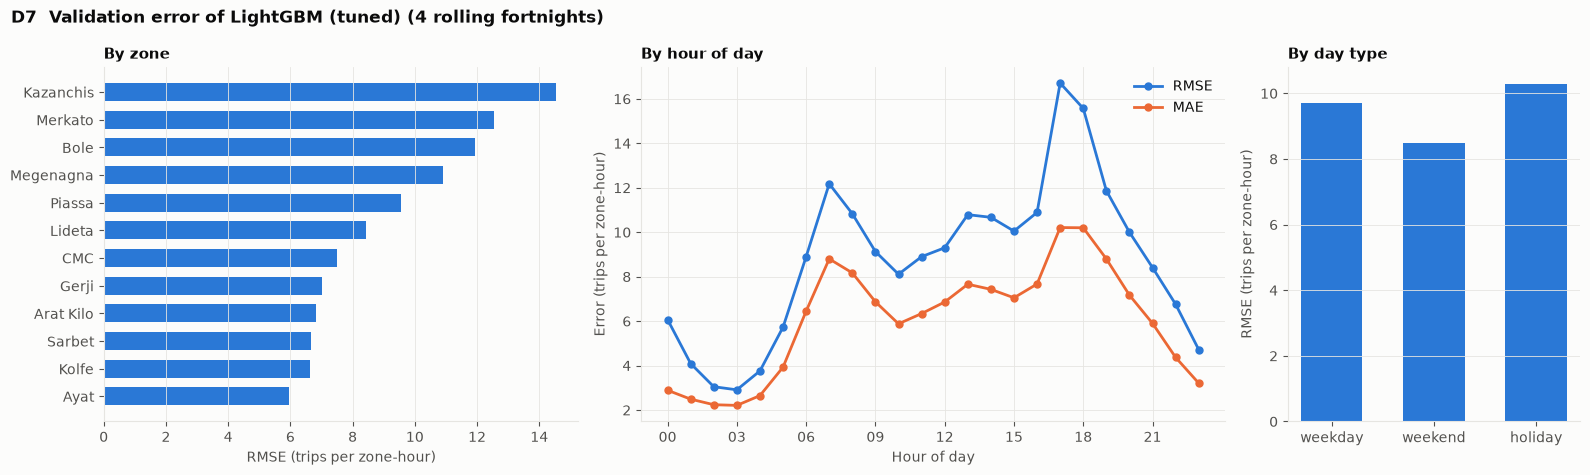

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1.3, 1.6, 0.8]})
axes[0].barh(by_zone.index[::-1], by_zone["rmse"][::-1], color=BLUE, height=0.65)
axes[0].set_xlabel("RMSE (trips per zone-hour)")
axes[0].set_title("By zone")
axes[0].grid(axis="y", visible=False)
axes[1].plot(by_hour.index, by_hour["rmse"], color=BLUE, marker="o", markersize=5, label="RMSE")
axes[1].plot(by_hour.index, by_hour["mae"], color=ORANGE, marker="o", markersize=5, label="MAE")
axes[1].set_xticks(range(0, 24, 3), [f"{h:02d}" for h in range(0, 24, 3)])
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Error (trips per zone-hour)")
axes[1].legend(frameon=False)
axes[1].set_title("By hour of day")
order = ["weekday", "weekend", "holiday"]
axes[2].bar(order, by_day.loc[order, "rmse"], color=BLUE, width=0.6)
axes[2].set_ylabel("RMSE (trips per zone-hour)")
axes[2].set_title("By day type")
axes[2].grid(axis="x", visible=False)
fig.suptitle(f"D7  Validation error of {FINAL_MODEL} (4 rolling fortnights)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "d7_error_analysis.png")

In [14]:
big = 2 * rmse(err["trips"], err["pred"])
err = err.sort_values(["zone", "pickup_hour"])
err["big_neighbours"] = (err.groupby("zone")["error"]
                           .transform(lambda e: (e.abs() > big).astype(int).rolling(7, center=True, min_periods=1).sum()) - 1)


def hypothesis(r):
    """Rule-based first guess for why a zone-hour has a large error."""
    if r["ev_in_window"]:
        return "listed event: crowd larger/smaller than expected"
    if r["is_holiday"]:
        return "public holiday: unusual pattern"
    if r["rain_mm"] > 1:
        return "rain hour: rain effect under-estimated"
    if r["error"] > 0 and r["big_neighbours"] >= 1:
        return "spike over several hours, no listed event: likely event missing from the calendar"
    if r["error"] > 0:
        return "one-hour spike, no listed event: random surge or unlisted event"
    return "demand far below expected: local disruption or partial data"


top10 = err.nlargest(10, "abs_error").copy()
top10["hypothesis"] = top10.apply(hypothesis, axis=1)
top10[["zone", "pickup_hour", "trips", "pred", "error", "day_type", "rain_mm", "ev_in_window", "big_neighbours", "hypothesis"]].round(1)

,zone,pickup_hour,trips,pred,error,day_type,rain_mm,ev_in_window,big_neighbours,hypothesis
5786,Kazanchis,2025-09-26 17:00:00,311,131.4,179.6,weekday,3.4,0,5.0,rain hour: rain effect under-estimated
5797,Kazanchis,2025-09-26 18:00:00,321,152.6,168.4,weekday,4.9,0,6.0,rain hour: rain effect under-estimated
10826,Kazanchis,2025-10-14 17:00:00,188,80.9,107.1,weekday,0.0,0,4.0,"spike over several hours, no listed event: lik..."
1320,Kazanchis,2025-09-10 17:00:00,266,161.9,104.1,weekday,0.0,1,4.0,listed event: crowd larger/smaller than expected
5791,Piassa,2025-09-26 17:00:00,198,109.4,88.6,weekday,3.4,0,4.0,rain hour: rain effect under-estimated
1300,Merkato,2025-09-10 15:00:00,167,82.0,85.0,weekday,0.6,0,5.0,"spike over several hours, no listed event: lik..."
1276,Merkato,2025-09-10 13:00:00,183,98.1,84.9,weekday,0.0,0,6.0,"spike over several hours, no listed event: lik..."
1332,Kazanchis,2025-09-10 18:00:00,230,149.4,80.6,weekday,0.0,1,5.0,listed event: crowd larger/smaller than expected
5512,Piassa,2025-09-25 17:00:00,153,74.3,78.7,weekday,9.7,0,2.0,rain hour: rain effect under-estimated
13903,Kazanchis,2025-10-25 18:00:00,58,132.5,-74.5,weekend,0.0,1,1.0,listed event: crowd larger/smaller than expected


In [15]:
print(top10.groupby("hypothesis").size().sort_values(ascending=False).to_string())
print(f"\nError bias by fold (actual - predicted): "
      f"{err.groupby('fold')['error'].mean().round(2).to_dict()}")

hypothesis
rain hour: rain effect under-estimated                                               4
listed event: crowd larger/smaller than expected                                     3
spike over several hours, no listed event: likely event missing from the calendar    3

Error bias by fold (actual - predicted): {1: 0.99, 2: 0.93, 3: 1.04, 4: 0.62}


## D8 — Response to findings

Change tried because of D7: **weight recent weeks more** when training (demand grew ~41% Jan→Oct, so the model under-predicts the latest fortnights — positive bias in D7). Sample weight = 0.5 for the oldest rows rising linearly to 1.5 for the newest. Same folds, same features, same parameters.

In [16]:
def recency_weighted(features, params):
    """LightGBM trained with linearly increasing weights on more recent rows."""
    @timed
    def fit_predict(train, val):
        age = (train["pickup_hour"].max() - train["pickup_hour"]) / (train["pickup_hour"].max() - train["pickup_hour"].min())
        m = lgb.LGBMRegressor(**{**LGBM_DEFAULT, **(params or {})})
        m.fit(train[features], train["trips"], sample_weight=1.5 - age.values,
              categorical_feature=[f for f in ZONE if f in features])
        return m.predict(val[features]), m
    return fit_predict


final_params = BEST_PARAMS if FINAL_MODEL == "LightGBM (tuned)" else {}
d8_scores, d8_oof, d8_fitted = evaluate({f"{FINAL_MODEL} + recency weights": recency_weighted(FEATURES, final_params)})
compare = summarise(pd.concat([scores[scores["model"] == FINAL_MODEL], d8_scores]))
d8_bias = d8_oof.assign(e=d8_oof["trips"] - d8_oof["pred"]).groupby("fold")["e"].mean().round(2).to_dict()
print(compare[["rmse_mean", "rmse_sd", "mae_mean"]].to_string())
print("bias by fold after the change:", d8_bias)
helped = compare["rmse_mean"].idxmin() != FINAL_MODEL
print("\nResult:", "it helped — adopted as the final model." if helped else "it did not help — kept the previous final model.")
if helped:
    scores = pd.concat([scores, d8_scores], ignore_index=True)
    oof = pd.concat([oof, d8_oof], ignore_index=True)
    fitted.update(d8_fitted)
    FINAL_MODEL = f"{FINAL_MODEL} + recency weights"
else:
    scores = pd.concat([scores, d8_scores], ignore_index=True)

                                    rmse_mean  rmse_sd  mae_mean
model                                                           
LightGBM (tuned)                        9.394    0.864     6.066
LightGBM (tuned) + recency weights      9.539    0.953     6.132
bias by fold after the change: {1: 0.72, 2: 0.89, 3: 0.43, 4: 0.51}

Result: it did not help — kept the previous final model.


## D9 — Plain-language metric

In [17]:
last = oof[(oof["model"] == FINAL_MODEL) & (oof["fold"] == len(CUTOFFS))]
r, a, mean_demand = rmse(last["trips"], last["pred"]), mae(last["trips"], last["pred"]), last["trips"].mean()
trips_per_driver = (data["trips"] / data["active_drivers"]).mean()
print(f"Trips per active driver per hour in the history: {trips_per_driver:.2f}\n")
print(f"On the last validation fortnight (18–31 Oct) a typical zone-hour has {mean_demand:.0f} trips. "
      f"Our forecast is off by about {a:.1f} trips on an average zone-hour (MAE, {100 * a / mean_demand:.0f}% of demand); "
      f"the RMSE of {r:.1f} trips ({100 * r / mean_demand:.0f}%) is larger because it weighs the occasional big miss more. "
      f"At about {trips_per_driver:.1f} trips per driver per hour, that is roughly {a / trips_per_driver:.0f} drivers too many "
      f"or too few in a typical zone-hour, and around {r / trips_per_driver:.0f} drivers in the busier, harder hours.")

Trips per active driver per hour in the history: 1.27

On the last validation fortnight (18–31 Oct) a typical zone-hour has 33 trips. Our forecast is off by about 6.0 trips on an average zone-hour (MAE, 18% of demand); the RMSE of 8.9 trips (27%) is larger because it weighs the occasional big miss more. At about 1.3 trips per driver per hour, that is roughly 5 drivers too many or too few in a typical zone-hour, and around 7 drivers in the busier, harder hours.


## fig10 — Model comparison

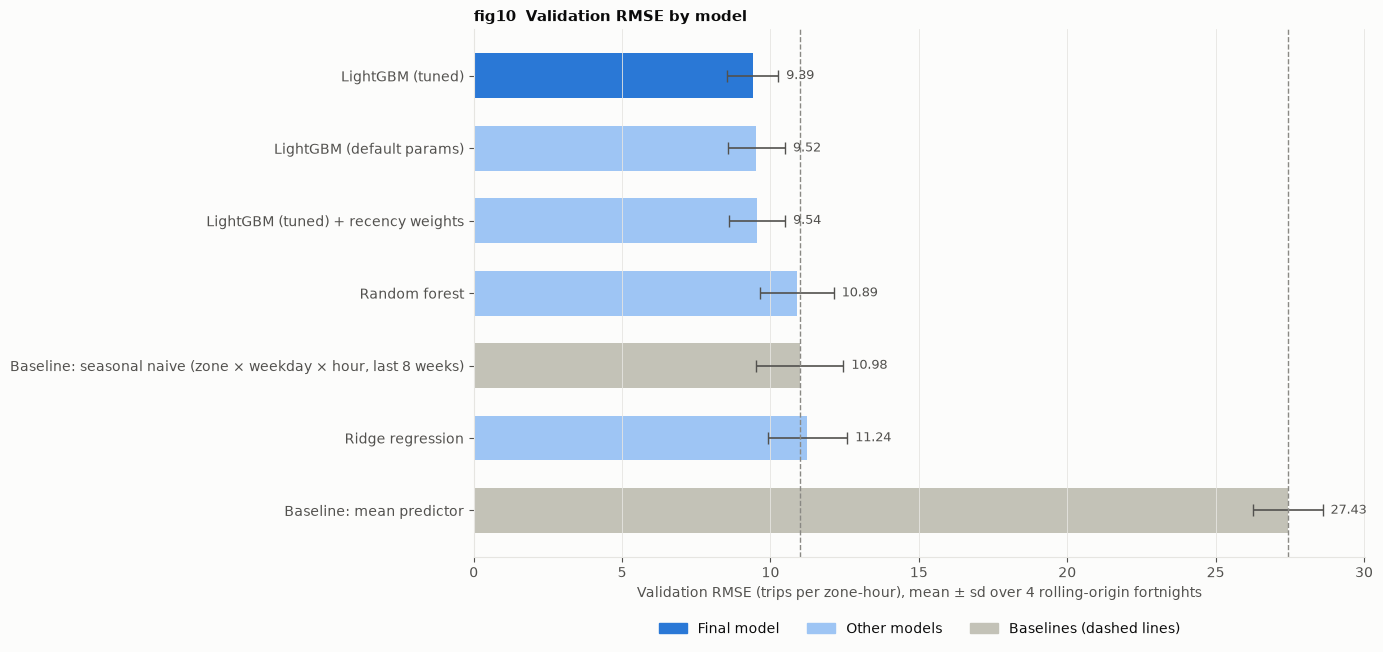

,rmse_mean,rmse_sd,mae_mean,mae_sd,train_s
model,,,,,
LightGBM (tuned),9.394,0.864,6.066,0.329,2.383
LightGBM (default params),9.521,0.967,6.120,0.353,4.925
LightGBM (tuned) + recency weights,9.539,0.953,6.132,0.336,2.664
Random forest,10.890,1.240,6.920,0.481,7.250
"Baseline: seasonal naive (zone × weekday × hour, last 8 weeks)",10.982,1.473,6.910,0.566,0.016
Ridge regression,11.244,1.341,7.384,0.551,0.709
Baseline: mean predictor,27.432,1.170,20.458,0.665,0.000


In [18]:
summary = summarise(scores)
results_out = scores.copy()
results_out.to_csv(PROC_DIR / "model_results.csv", index=False)
order = summary.index.tolist()
is_base = [m.startswith("Baseline") for m in order]
colors = [NEUTRAL if b else (BLUE if m == FINAL_MODEL else LIGHT_BLUE) for m, b in zip(order, is_base)]
fig, ax = plt.subplots(figsize=(11.5, 0.75 * len(order) + 1.6))
y = np.arange(len(order))
ax.barh(y, summary["rmse_mean"], xerr=summary["rmse_sd"], color=colors, height=0.62,
        error_kw=dict(ecolor=INK_2, elinewidth=1.2, capsize=4))
for yi, m in enumerate(order):
    ax.text(summary.loc[m, "rmse_mean"] + summary.loc[m, "rmse_sd"], yi, f"  {summary.loc[m, 'rmse_mean']:.2f}",
            va="center", fontsize=9, color=INK_2)
for m in [m for m, b in zip(order, is_base) if b]:
    ax.axvline(summary.loc[m, "rmse_mean"], color=INK_3, linestyle="--", linewidth=1)
ax.set_yticks(y, order)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel(f"Validation RMSE (trips per zone-hour), mean ± sd over {len(CUTOFFS)} rolling-origin fortnights")
ax.legend(handles=[Patch(color=BLUE, label="Final model"), Patch(color=LIGHT_BLUE, label="Other models"),
                   Patch(color=NEUTRAL, label="Baselines (dashed lines)")], frameon=False,
          loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
ax.set_title("fig10  Validation RMSE by model")
save(fig, "fig10_model_comparison.png")
summary

## fig11 — Forecast vs actual

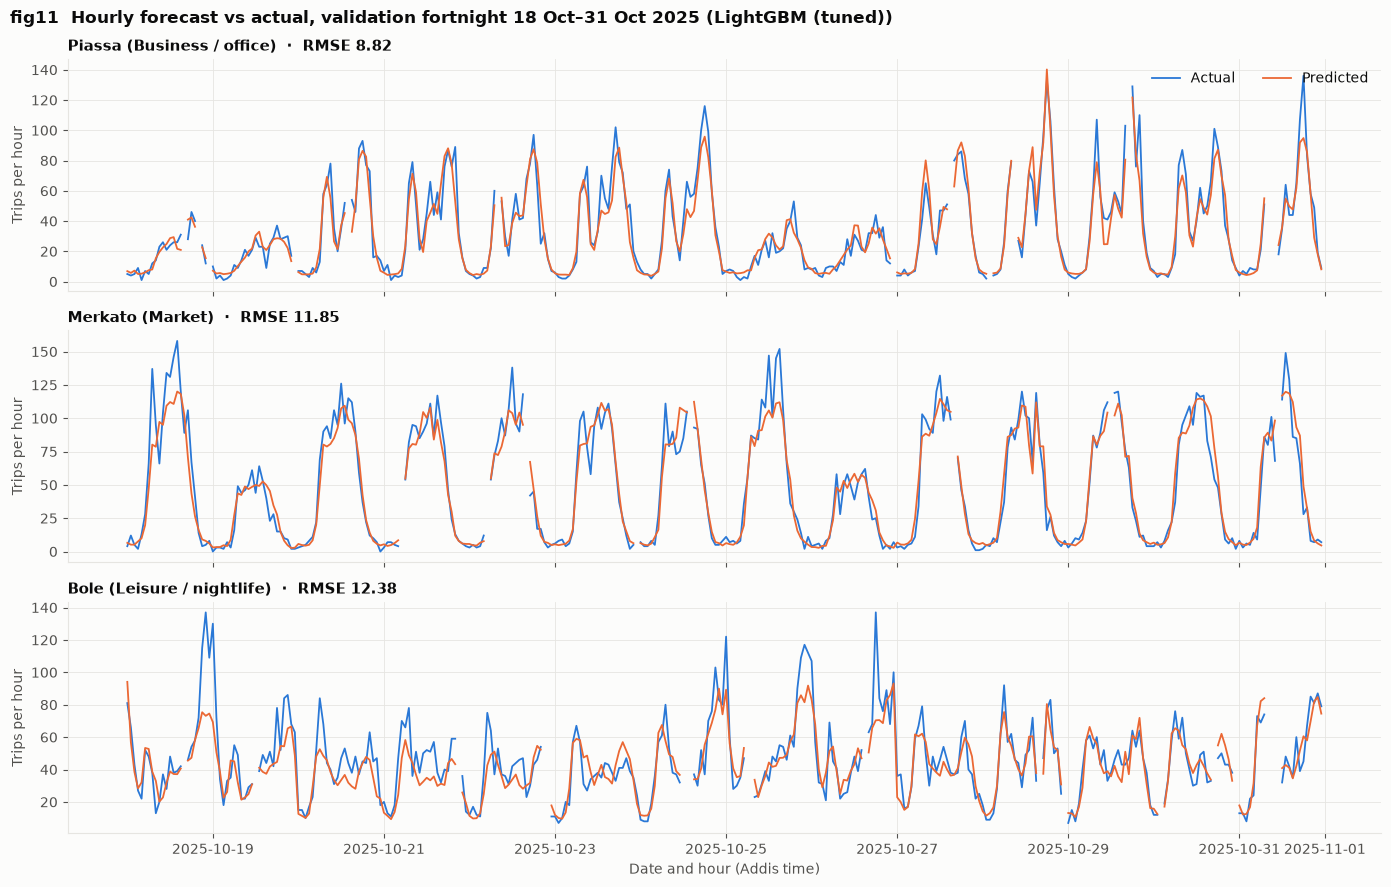

In [19]:
SHOW_ZONES = ["Piassa", "Merkato", "Bole"]
start = CUTOFFS[-1]
full = pd.date_range(start, start + HORIZON - pd.Timedelta(hours=1), freq="h")
fig, axes = plt.subplots(len(SHOW_ZONES), 1, figsize=(14, 9), sharex=True)
for ax, z in zip(axes, SHOW_ZONES):
    s = last[last["zone"] == z].set_index("pickup_hour").reindex(full)
    ax.plot(full, s["trips"], color=BLUE, linewidth=1.3, label="Actual")
    ax.plot(full, s["pred"], color=ORANGE, linewidth=1.3, label="Predicted")
    ok = s["trips"].notna()
    ax.set_title(f"{z} ({zone_type[z].split(' (')[0]})  ·  RMSE {rmse(s.loc[ok, 'trips'], s.loc[ok, 'pred']):.2f}")
    ax.set_ylabel("Trips per hour")
axes[-1].set_xlabel("Date and hour (Addis time)")
axes[0].legend(frameon=False, ncol=2, loc="upper right")
fig.suptitle(f"fig11  Hourly forecast vs actual, validation fortnight {start:%d %b}–{full[-1]:%d %b %Y} ({FINAL_MODEL})",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig11_forecast_vs_actual.png")

## fig12 — Feature importance

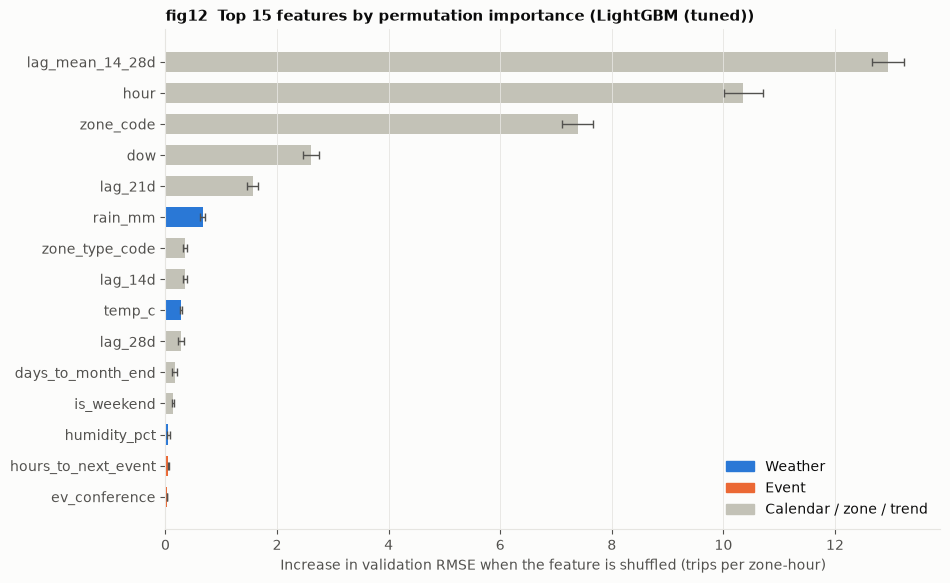

,feature,mean,std,group
0,lag_mean_14_28d,12.943,0.286,Calendar / zone / trend
1,hour,10.359,0.345,Calendar / zone / trend
2,zone_code,7.385,0.274,Calendar / zone / trend
3,dow,2.606,0.143,Calendar / zone / trend
4,lag_21d,1.564,0.097,Calendar / zone / trend
5,rain_mm,0.664,0.041,Weather
6,zone_type_code,0.350,0.034,Calendar / zone / trend
7,lag_14d,0.349,0.036,Calendar / zone / trend
8,temp_c,0.282,0.018,Weather
9,lag_28d,0.276,0.053,Calendar / zone / trend


In [20]:
final = fitted[(FINAL_MODEL, len(CUTOFFS))]
_, val = split(CUTOFFS[-1])
pi = permutation_importance(final, val[FEATURES], val["trips"], scoring="neg_root_mean_squared_error",
                            n_repeats=5, random_state=SEED, n_jobs=1)
importance = pd.DataFrame({"feature": FEATURES, "mean": pi.importances_mean, "std": pi.importances_std}) \
               .sort_values("mean", ascending=False).reset_index(drop=True)
importance["group"] = importance["feature"].map(FEATURE_GROUP).fillna("Calendar / zone / trend")
importance.to_csv(PROC_DIR / "feature_importance.csv", index=False)

TOP = 15
top = importance.head(TOP).iloc[::-1]
group_color = {"Weather": BLUE, "Event": ORANGE, "Calendar / zone / trend": NEUTRAL}
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(top["feature"], top["mean"], xerr=top["std"], color=top["group"].map(group_color), height=0.65,
        error_kw=dict(ecolor=INK_2, elinewidth=1, capsize=3))
ax.grid(axis="y", visible=False)
ax.set_xlabel("Increase in validation RMSE when the feature is shuffled (trips per zone-hour)")
ax.legend(handles=[Patch(color=c, label=g) for g, c in group_color.items()], frameon=False, loc="lower right")
ax.set_title(f"fig12  Top {TOP} features by permutation importance ({FINAL_MODEL})")
save(fig, "fig12_feature_importance.png")
importance.head(TOP).round(3)

## Final model → test predictions (1–14 Nov 2025)

The final model is re-trained on **all** cleaned train rows (1 Jan – 31 Oct 2025) with the chosen settings, then predicts every test row. Test features come from `master_test.csv`, built by the same pipeline as train; lags use only train history and November weather is the forecast in the weather file. `predicted_trips` is rounded to whole trips (the model predicts an expected count; rounding changed validation RMSE by less than 0.01). The submission keeps the test file's original row order.

In [21]:
TEAM = "flowcode"
test = pd.read_csv(PROC_DIR / "master_test.csv", parse_dates=["pickup_hour"])
type_codes = dict(zip(data["zone_type"], data["zone_type_code"]))
test["zone_code"] = test["zone"].map({z: i for i, z in enumerate(ZONES)})
test["zone_type"] = test["zone"].map(zone_type)
test["zone_type_code"] = test["zone_type"].map(type_codes)
assert test[FEATURES].shape[1] == len(FEATURES) and test[ZONE].notna().all().all()

final_fn = recency_weighted(FEATURES, final_params) if FINAL_MODEL.endswith("recency weights") else lgbm(FEATURES, final_params)
pred, final_full, secs = final_fn(data, test)
test["trips_pred"] = np.clip(pred, 0, None)
test["predicted_trips"] = test["trips_pred"].round().astype(int)

raw_order = pd.read_csv(ROOT / "data" / "raw" / "ride_demand_test.csv", usecols=["row_id"])
submission = raw_order.merge(test[["row_id", "predicted_trips"]], on="row_id", how="left", validate="one_to_one")
SUB_DIR = ROOT / "submission"
SUB_DIR.mkdir(exist_ok=True)
submission.to_csv(SUB_DIR / f"team_{TEAM}_submission.csv", index=False)
test[["row_id", "zone", "pickup_hour", "trips_pred", "predicted_trips"]].to_csv(PROC_DIR / "test_predictions.csv", index=False)

check = pd.read_csv(SUB_DIR / f"team_{TEAM}_submission.csv")
assert list(check.columns) == ["row_id", "predicted_trips"]
assert len(check) == 4032 and check["row_id"].is_unique and (check["row_id"] == raw_order["row_id"]).all()
assert check["predicted_trips"].notna().all() and (check["predicted_trips"] >= 0).all()
assert pd.api.types.is_numeric_dtype(check["predicted_trips"])
print(f"G4 checks passed: submission/team_{TEAM}_submission.csv — 4,032 rows, row_id + predicted_trips, original order, no blanks or negatives")
print(f"{FINAL_MODEL} trained on {len(data):,} rows ({data['pickup_hour'].min():%d %b} – {data['pickup_hour'].max():%d %b %Y}) "
      f"in {secs:.1f}s with params {final_params}")
recent = data[data["pickup_hour"] >= "2025-10-18"]
print(f"mean predicted trips per zone-hour {test['trips_pred'].mean():.1f} vs last train fortnight actual {recent['trips'].mean():.1f}")
pd.DataFrame({"predicted Nov 1–14": test.groupby("zone")["trips_pred"].mean(),
              "actual Oct 18–31": recent.groupby("zone")["trips"].mean()}).round(1)

G4 checks passed: submission/team_flowcode_submission.csv — 4,032 rows, row_id + predicted_trips, original order, no blanks or negatives
LightGBM (tuned) trained on 82,742 rows (01 Jan – 31 Oct 2025) in 3.1s with params {'subsample': 0.8, 'reg_lambda': 10.0, 'objective': 'tweedie', 'num_leaves': 15, 'n_estimators': 1000, 'min_child_samples': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
mean predicted trips per zone-hour 32.8 vs last train fortnight actual 33.4


,predicted Nov 1–14,actual Oct 18–31
zone,,
Arat Kilo,23.7,24.0
Ayat,21.0,21.4
Bole,43.8,45.9
CMC,29.8,30.0
Gerji,28.4,28.8
Kazanchis,37.6,38.7
Kolfe,26.3,26.9
Lideta,32.9,33.5
Megenagna,42.5,44.1


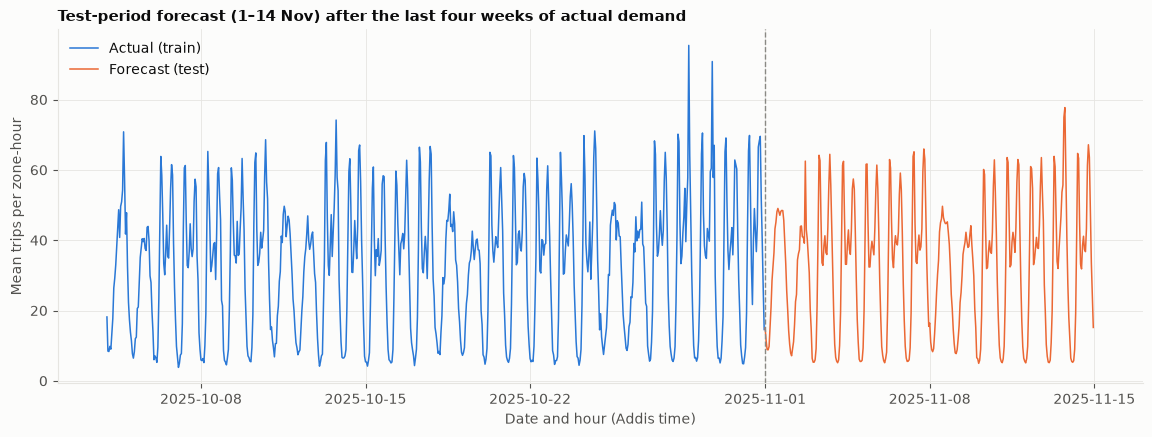

In [22]:
city_hist = data[data["pickup_hour"] >= "2025-10-04"].groupby("pickup_hour")["trips"].mean()
city_pred = test.groupby("pickup_hour")["trips_pred"].mean()
fig, ax = plt.subplots(figsize=(14, 4.6))
ax.plot(city_hist.index, city_hist.values, color=BLUE, linewidth=1.1, label="Actual (train)")
ax.plot(city_pred.index, city_pred.values, color=ORANGE, linewidth=1.1, label="Forecast (test)")
ax.axvline(test["pickup_hour"].min(), color=INK_3, linestyle="--", linewidth=1)
ax.set_xlabel("Date and hour (Addis time)")
ax.set_ylabel("Mean trips per zone-hour")
ax.legend(frameon=False, loc="upper left")
ax.set_title("Test-period forecast (1–14 Nov) after the last four weeks of actual demand")
save(fig, "test_forecast_city.png")

## Export the final model and the app's bundled lookup tables

`models/final_model.joblib` holds the trained model plus everything needed to build its inputs (feature order, zone codes, zone types), its settings, validation scores and library versions; `final_model_lightgbm.txt` is the same model in LightGBM's own format as a version-proof fallback. The demo app reads only `app/assets/`: the model, the November feature rows, the cleaned events and weather, each zone's average fare and typical profile from the history, and the validation results.

In [23]:
import json
import shutil
import joblib
import sklearn

MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
final_scores = summarise(scores).loc[FINAL_MODEL]
bundle = {
    "model": final_full,
    "model_name": FINAL_MODEL,
    "features": FEATURES,
    "feature_groups": {"calendar": CALENDAR, "zone": ZONE, "trend": TREND, "weather": WEATHER, "events": EVENTS},
    "zone_codes": {z: i for i, z in enumerate(ZONES)},
    "zone_type": zone_type.to_dict(),
    "zone_type_codes": {k: int(v) for k, v in type_codes.items()},
    "params": {**LGBM_DEFAULT, **final_params},
    "trained_on": f"{data['pickup_hour'].min():%Y-%m-%d %H:%M} to {data['pickup_hour'].max():%Y-%m-%d %H:%M} (Addis time)",
    "n_train_rows": len(data),
    "trips_per_driver_hour": float((data["trips"] / data["active_drivers"]).median()),
    "validation": {"rmse_mean": float(final_scores["rmse_mean"]), "rmse_sd": float(final_scores["rmse_sd"]),
                   "mae_mean": float(final_scores["mae_mean"]), "folds": [str(c.date()) for c in CUTOFFS],
                   "horizon_days": 14},
    "versions": {"lightgbm": lgb.__version__, "scikit-learn": sklearn.__version__,
                 "pandas": pd.__version__, "numpy": np.__version__},
}
joblib.dump(bundle, MODEL_DIR / "final_model.joblib")
final_full.booster_.save_model(str(MODEL_DIR / "final_model_lightgbm.txt"))
(MODEL_DIR / "model_metadata.json").write_text(json.dumps({k: v for k, v in bundle.items() if k != "model"}, indent=1))
loaded = joblib.load(MODEL_DIR / "final_model.joblib")
assert np.allclose(np.clip(loaded["model"].predict(test[loaded["features"]]), 0, None), test["trips_pred"])

ASSETS = ROOT / "app" / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)
for f in ["final_model.joblib", "final_model_lightgbm.txt", "model_metadata.json"]:
    shutil.copy(MODEL_DIR / f, ASSETS / f)
test.drop(columns=["trips_pred", "predicted_trips"]).to_csv(ASSETS / "test_features.csv", index=False)
events_all = pd.read_csv(PROC_DIR / "events_clean.csv")
events_all[events_all["is_cancelled"] == 0].to_csv(ASSETS / "events.csv", index=False)
weather_all = pd.read_csv(PROC_DIR / "weather_clean.csv", parse_dates=["timestamp"])
weather_all[weather_all["timestamp"] >= "2025-10-31"].to_csv(ASSETS / "weather.csv", index=False)
trips_hist = pd.read_csv(PROC_DIR / "trips_clean.csv", parse_dates=["pickup_hour"])
fares = trips_hist[trips_hist["fare_imputed"] == 0].groupby("zone")["avg_fare_birr"].mean().round(1).rename("avg_fare_birr")
fares.to_csv(ASSETS / "zone_fares.csv")
recent8 = trips_hist[trips_hist["pickup_hour"] >= trips_hist["pickup_hour"].max() - pd.Timedelta(weeks=8)]
typical = (recent8.assign(dow=recent8["pickup_hour"].dt.dayofweek, hour=recent8["pickup_hour"].dt.hour)
                  .groupby(["zone", "dow", "hour"])["trips"].mean().round(2).rename("typical_trips"))
typical.to_csv(ASSETS / "typical_profile.csv")
recent14 = trips_hist[trips_hist["pickup_hour"] > trips_hist["pickup_hour"].max() - pd.Timedelta(days=14)]
recent14[["zone", "pickup_hour", "trips"]].to_csv(ASSETS / "recent_actuals.csv", index=False)
scores.to_csv(ASSETS / "model_results.csv", index=False)
importance.to_csv(ASSETS / "feature_importance.csv", index=False)
print("app/assets:", {p.name: f"{p.stat().st_size / 1024:.0f} KB" for p in sorted(ASSETS.iterdir())})
print({k: v for k, v in bundle.items() if k not in ("model", "features", "feature_groups", "zone_type", "zone_codes", "zone_type_codes")})

app/assets: {'.gitkeep': '0 KB', 'events.csv': '40 KB', 'feature_importance.csv': '2 KB', 'final_model.joblib': '1735 KB', 'final_model_lightgbm.txt': '1732 KB', 'model_metadata.json': '3 KB', 'model_results.csv': '3 KB', 'recent_actuals.csv': '118 KB', 'test_features.csv': '790 KB', 'typical_profile.csv': '36 KB', 'weather.csv': '16 KB', 'zone_fares.csv': '0 KB'}
{'model_name': 'LightGBM (tuned)', 'params': {'objective': 'tweedie', 'n_estimators': 1000, 'learning_rate': 0.1, 'num_leaves': 15, 'min_child_samples': 20, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.9, 'random_state': 42, 'verbose': -1, 'reg_lambda': 10.0}, 'trained_on': '2025-01-01 00:00 to 2025-10-31 23:00 (Addis time)', 'n_train_rows': 82742, 'trips_per_driver_hour': 1.3076923076923077, 'validation': {'rmse_mean': 9.394, 'rmse_sd': 0.864, 'mae_mean': 6.066, 'folds': ['2025-09-06', '2025-09-20', '2025-10-04', '2025-10-18'], 'horizon_days': 14}, 'versions': {'lightgbm': '4.7.0', 'scikit-learn': '1.9.1', 'p